# Goal 1：实际角色、修复返回与离线复算

对应教师《任务3_LLM辅助评估清洗》的工作入口。本轮 A、B-Run / B-Repair、C 使用主会话实际派发的原生角色任务；确定性 Goal journal 记录职责、产物、审核和恢复。一个输出不会被重复标成多个角色。

历史 4 次初始 CLI 派发与后续 6 次修复 CLI 调用独立保留，不等于本轮 native 角色数量。默认只读取真实记录并从 raw 重算工具，新模型调用为 0；不重跑旧六次对话。

In [1]:
from pathlib import Path
import json, sys, html
from IPython.display import display, HTML, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from task1.workflow.io import DATA, CONFIG, EVIDENCE, read_json, digest, object_hash
from task1.workflow.tools import execute_tool
from task1.scripts.build_complete_figures import load_current
REVISION = EVIDENCE/'revisions/SC-LAB1-G1-COMPLETE-001'
current, manifest, saved_baseline = load_current()
policy = read_json(CONFIG)
record_ids = manifest['record_scope']
raw = read_json(DATA)
assert digest(DATA) == manifest['input_sha256'] == policy['raw_sha256']

def show_table(rows):
    if not rows:
        print('No rows')
        return
    columns = list(rows[0])
    def cell(value):
        return html.escape(json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else str(value))
    header = ''.join('<th style="text-align:left;padding:6px">'+cell(c)+'</th>' for c in columns)
    body = ''.join('<tr>'+''.join('<td style="padding:6px;vertical-align:top">'+cell(row.get(c, ''))+'</td>' for c in columns)+'</tr>' for row in rows)
    display(HTML('<table><thead><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))

print('Current run:', current['run_id'])
print('Processing CODE_SHA:', manifest['code_sha'])
print('Raw SHA256:', digest(DATA))
print('Fixed development record scope:', record_ids)
print('Default mode: RECOMPUTE; new model calls: 0')

Current run: g1-complete-pilot-03
Processing CODE_SHA: f229d9a4113bcc0dd763e1b410f1f5fb73903a62
Raw SHA256: c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3
Fixed development record scope: ['0', '1', '2', '246', '256', '306', '352']
Default mode: RECOMPUTE; new model calls: 0


In [2]:
MODE='RECOMPUTE'
ENABLE_LIVE=False
LIVE_RUN_ID=None
assert MODE in ('RECOMPUTE','LIVE')
print('Selected mode:',MODE)

Selected mode: RECOMPUTE


## 当前产物及目标覆盖

每个审核回执绑定具体目标 ID/hash、原始参考、记录集合、合同和完整检查组件。旧 profiles 的通过不代替新 time boundaries、duplicate details 或 baseline 的审核。

In [3]:
artifact_rows=[]
for action, artifact in manifest['artifacts'].items():
    review_entry=manifest['reviews'].get(action)
    review=read_json(ROOT/review_entry['path'])['result'] if review_entry else {}
    artifact_rows.append({'action':action, 'artifact_id':artifact['artifact_id'], 'sha256':artifact['sha256'], 'review_status':review.get('status','NOT_RUN'), 'checked':review.get('checked_components',[]), 'unchecked':review.get('unchecked_components',[])})
show_table(artifact_rows)

action,artifact_id,sha256,review_status,checked,unchecked
profile_pilot,g1-complete-pilot-03:profile_pilot,ed6d427bf712a433650bc28238ce58522065ad8dfc754301733ea005cb30ac71,VERIFIED,"[""record_scope"", ""profile_fields"", ""profile_counts"", ""summary""]",[]
duplicate_details,g1-complete-pilot-03:duplicate_details,2af0cd5d718fa8cc5bd955eeea4c1fdd05374d7a173fdf9d9bc1c56f0d49e32d,VERIFIED,"[""record_scope"", ""complete_events"", ""event_types"", ""event_indices""]",[]
time_boundaries,g1-complete-pilot-03:time_boundaries,bf0b0e9da04e08e170d98907cde40959d5325619ec2f2377db44c11d053a7edd,VERIFIED,"[""record_scope"", ""raw_time"", ""threshold"", ""strict_inequality"", ""boundaries"", ""index_order"", ""point_coverage""]",[]
baseline,g1-complete-pilot-03:baseline,865710aea34a316fe83088d7cf2ac1aec68c96623269bfcf06255b5db2930fd8,VERIFIED,"[""provenance"", ""contract"", ""segmentation"", ""filtering"", ""direction"", ""actual_values"", ""dp_intervals"", ""point_accounting"", ""summaries""]",[]


## 从 raw 实际重算当前运行

`recompute_saved` 先核对输入、合同和代码 hash，再重新执行实际工具，由独立谓词审核新输出并比较保存产物。它不只是读取旧 CSV，也不是 snapshot 与自身比较。源码或合同发生变化会要求重建，不能继续借旧结果完成任务。

In [4]:
if MODE=='RECOMPUTE':
    from task1.scripts.complete_goal1 import recompute_saved
    recomputed=recompute_saved(current['run_id'])
    assert recomputed['new_model_calls']==0 and recomputed['status']=='VERIFIED', recomputed
    show_table([{'action':r['action'], 'fresh_output_matches':r['exact_match'], 'independent_review':r.get('independent_review',{}).get('status',r.get('status')), 'unchecked':r.get('independent_review',{}).get('unchecked_components',[])} for r in recomputed['checks']])
else:
    assert ENABLE_LIVE, 'LIVE 必须显式启用'
    assert policy['live_execution_enabled'], policy['live_stop_reason']
    assert LIVE_RUN_ID and not (EVIDENCE/'runs'/LIVE_RUN_ID).exists(), 'LIVE 使用新 run_id；不清空累计预算'
    from task1.workflow.controller import Controller
    live_result=Controller(LIVE_RUN_ID).run()
    print('Controlled existing-provider run:',live_result['status'])

action,fresh_output_matches,independent_review,unchecked
profile_pilot,True,VERIFIED,[]
duplicate_details,True,VERIFIED,[]
time_boundaries,True,VERIFIED,[]
baseline,True,VERIFIED,[]


## 真实 A / B / C 交接及资源

下方读取本轮资源记录与 A 的任务交接路径。CLI、native 派发、完成 turn、工具动作分开计数；不可观察的底层请求保持 unknown。本 Notebook 的确定性重算不冒充新的模型回应。

In [5]:
resources=read_json(REVISION/'resources.json')
show_table([{'historical_batch':k, 'dispatches':v} for k,v in resources['historical_dispatches'].items() if k!='source'])
show_table(resources.get('actual_native_dispatches',[]))
print('Completed role turns:',resources.get('completed_role_turns','unknown'))
print('This execution CLI dispatches:',resources.get('cli_dispatches','unknown'))
print('Hidden provider requests:',resources.get('hidden_provider_requests','unknown'))
print('Guardrails:',resources['guardrails'])
a_path=REVISION/'a_scope/TaskPlan.json'
a_plan=read_json(a_path)
print('A handoff:',a_path.relative_to(ROOT),'SHA256:',digest(a_path))
print('A artifact type:',a_plan.get('artifact_type'))

historical_batch,dispatches
original,4
repair_001,6


operation,target,role,task
spawn_agent,/root/c_defects,C,external C2 reproduction
spawn_agent,/root/a_scope,A,requirements and source audit
spawn_agent,/root/b_baseline,B-Repair,trusted baseline implementation
followup_task,/root/c_defects,C,F01 independent new counterexamples
followup_task,/root/a_scope,A,conditional model and threshold check plan after new user authorization
followup_task,/root/c_defects,C,F01 regression after rejection
followup_task,/root/c_defects,C,F02 independent hand-constructed candidates and repeat
followup_task,/root/b_baseline,B-Run,Notebook and native figure production
followup_task,/root/c_defects,C,version-aligned F01/F02 and actual followup gate independent verification
followup_task,/root/c_defects,C,"repair regression for fixed followup coverage, legal complete scope and finalize"


Completed role turns: unknown; native tool does not export a reliable provider turn counter
This execution CLI dispatches: 0
Hidden provider requests: unknown
Guardrails: {'max_concurrent_children': 3, 'initial_role_task_budget': 10, 'reason': 'bounded repairs and independent final verification; adjust explicitly only with new evidence', 'additional_paid_api': False, 'new_provider': False, 'repeat_identical_requests': False, 'planned_native_dispatch_ceiling': 14}
A handoff: task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/a_scope/TaskPlan.json SHA256: fb4ccd560b7c133888fb65b78125a82c4149da4c8ae79c39d4350b97a0817f90
A artifact type: A_ROLE_TASKPLAN_HANDOFF


## Issue → B-Repair → C → 受影响产物重建 → 父任务恢复

C2-F01/F02 来自真实外部 GPT 审核，不能称为本轮角色自行新发现。B 在同一执行中消费缺陷并修代码；C 独立反例核验后才允许关闭，未通过则重新修复。源代码变更使受影响结果失效，父任务必须恢复并处理剩余项。以下状态和附件来自实际 journal，不预设固定次数成功。

In [6]:
state=read_json(REVISION/'goal_state.json')
show_table([{'issue':key, 'source':row['source'], 'parent_task':row['parent_task'], 'repairer':row['repairer'], 'verifier':row.get('verifier'), 'status':row['status'], 'repair_evidence':row.get('repair_evidence',[]), 'closure_evidence':row.get('closure_evidence',[])} for key,row in state['issues'].items()])
event_kinds={'ISSUE_OPENED','B_REPAIR_CONSUMED','REPAIR_SUBMITTED','C_REOPENED','C_VERIFIED_PARENT_RESUMED','CODE_BOUND','RUN_STARTED','TOOL_EXECUTED','FOLLOWUP_DISPATCHED','FOLLOWUP_EXECUTED','TASK_VERIFIED','GOAL_REEVALUATED'}
show_table([{'sequence':e['sequence'], 'kind':e['kind'], 'issue_or_task':e.get('issue_id',e.get('task','')), 'run_or_operation':e.get('run_id',e.get('operation','')), 'parent_task':e.get('parent_task','')} for e in state['events'] if e['kind'] in event_kinds])

issue,source,parent_task,repairer,verifier,status,repair_evidence,closure_evidence
C2-F01,GPT external review; independently reproduced by C:c_defects,review_targets,B-Repair:root,C:c_defects,VERIFIED,"[{""path"": ""task1/workflow/goal.py"", ""sha256"": ""d313d408961adf07b9791972b03ac6a99db808e805efe1aa06abe85a075e863a""}, {""path"": ""task1/workflow/tools.py"", ""sha256"": ""0fde0acebfe3ec97bd2653744ac8f0444c1e9a162c61970bccf8a94a9fbd0b3f""}, {""path"": ""task1/workflow/artifact_review.py"", ""sha256"": ""dfa0b91149662baf26861a9ec0e51223842d0ac62ada29015eca7b119c68da48""}, {""path"": ""task1/tests/test_goal_completion.py"", ""sha256"": ""0270360da4c692dcce8ed2d6b6a2fff3f12c7b08d42043788db15974deecd5e8""}]","[{""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_combined_review/combined_closure.json"", ""sha256"": ""83073242a00302bdb0c87da91f30853790d9ce1454967dbaac5560d4afe350da""}, {""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_combined_review/round2/combined_closure.json"", ""sha256"": ""a67d902f1e878c36f7451f4deff258f4a0d0747dbdc093ea783a72b3e4f8446b""}]"
C2-F02,GPT external review; independently reproduced by C:c_defects,trusted_baseline,B-Repair:root,C:c_defects,VERIFIED,"[{""path"": ""task1/workflow/pipeline.py"", ""sha256"": ""160bedcc0d8dffce71d833dffc4de28928bc7007077ae8d03c57c96d827548c7""}, {""path"": ""task1/workflow/evaluation.py"", ""sha256"": ""92424a94c20ce897606d546ba69c0f205c0f5f75a17b609134ac8125a241c7ad""}, {""path"": ""task1/tests/test_baseline_trust.py"", ""sha256"": ""fcf87df8872903d0aca13b31a67004247dae3135b6ddb4c2aff31ca0993b0bd5""}]","[{""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_f02_review/initial_review.json"", ""sha256"": ""ad4bbfe762de378809f4fc4b9a381139afcaeb1ba28e95bf307007b9ef5729c7""}, {""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_combined_review/combined_closure.json"", ""sha256"": ""83073242a00302bdb0c87da91f30853790d9ce1454967dbaac5560d4afe350da""}]"
NUMERIC:g1-complete-pilot-01:baseline,independent numeric runtime check,real_baseline,B-Repair:b_baseline,C:c_acceptance,VERIFIED,"[{""path"": ""task1/workflow/evaluation.py"", ""sha256"": ""7cf224fbc290d3e83acd5d83a3fe335e6dc437c762f7053d8132817aa91025b2""}, {""path"": ""task1/tests/test_baseline_trust.py"", ""sha256"": ""bd962103d7b7eef682e172b8e839247dc508242aa7cb27bdfa9f7363addae848""}, {""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/b_repair/direction_roundoff/root_cause.json"", ""sha256"": ""9a514a8a0f4004c38931e1f896869ef895d97cb6d158d1fa44dbef57b8c86970""}, {""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/b_repair/direction_roundoff/candidate_recheck.json"", ""sha256"": ""9eecda035cd3fecfbf43c6d294549ce8b3496bd37317e0b73593f4f4445d7bef""}]","[{""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_acceptance/direction_roundoff_receipt.json"", ""sha256"": ""1003de087bf2f71561bb75add022491af8e33bb05795bf1b4cf62b7073405a18""}]"
C3-COORDINATE-DIRECTION,C:c_acceptance independent static review,processing_feedback,B-Repair:root,C:c_acceptance,VERIFIED,"[{""path"": ""task1/workflow/coordinate_review.py"", ""sha256"": ""af4f0d753d162666bcb5da07edeccb846e008c33adf0f56b34939ac526eaf951""}, {""path"": ""task1/tests/test_coordinates.py"", ""sha256"": ""514cb0823d15df24f035bc2d595fd4c673d7171d713faf11cb7d429cb61e5329""}]","[{""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_acceptance/coordinate_issue_receipt.json"", ""sha256"": ""54dcc9ecd8a353b4382fb6beb921853a1fcd754082964f31941fe49bfadeb976""}]"
C3-TIME-SCOPE,C:c_acceptance independent current artifact inspection,diagnostics,B-Repair:root,C:c_acceptance,VERIFIED,"[{""path"": ""task1/workflow/diagnostics.py"", ""sha256"": ""aee1e4dd46ff7b15a8f3d854aaf1ed9668ee5ef4d4991a624beb479ff0f82745""}]","[{""path"": ""task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_acceptance/time_scope_receipt.json"", ""sha256"": ""fde6c11494e7d07a49e33f5

sequence,kind,issue_or_task,run_or_operation,parent_task
0,ISSUE_OPENED,C2-F01,,
1,B_REPAIR_CONSUMED,C2-F01,,
2,ISSUE_OPENED,C2-F02,,
3,B_REPAIR_CONSUMED,C2-F02,,
4,GOAL_REEVALUATED,,,
6,REPAIR_SUBMITTED,C2-F02,,
8,C_REOPENED,C2-F02,,
9,B_REPAIR_CONSUMED,C2-F02,,
10,REPAIR_SUBMITTED,C2-F02,,
11,REPAIR_SUBMITTED,C2-F01,,


## 执行结构与真实后续动作

结构图表示当前实现及实际角色职责，不是 Evidence Master 的全局互动演变图。真实处理后的 follow-up 请求、执行产物和复验均应绑定 baseline；没有结果时保持 NOT_RUN。

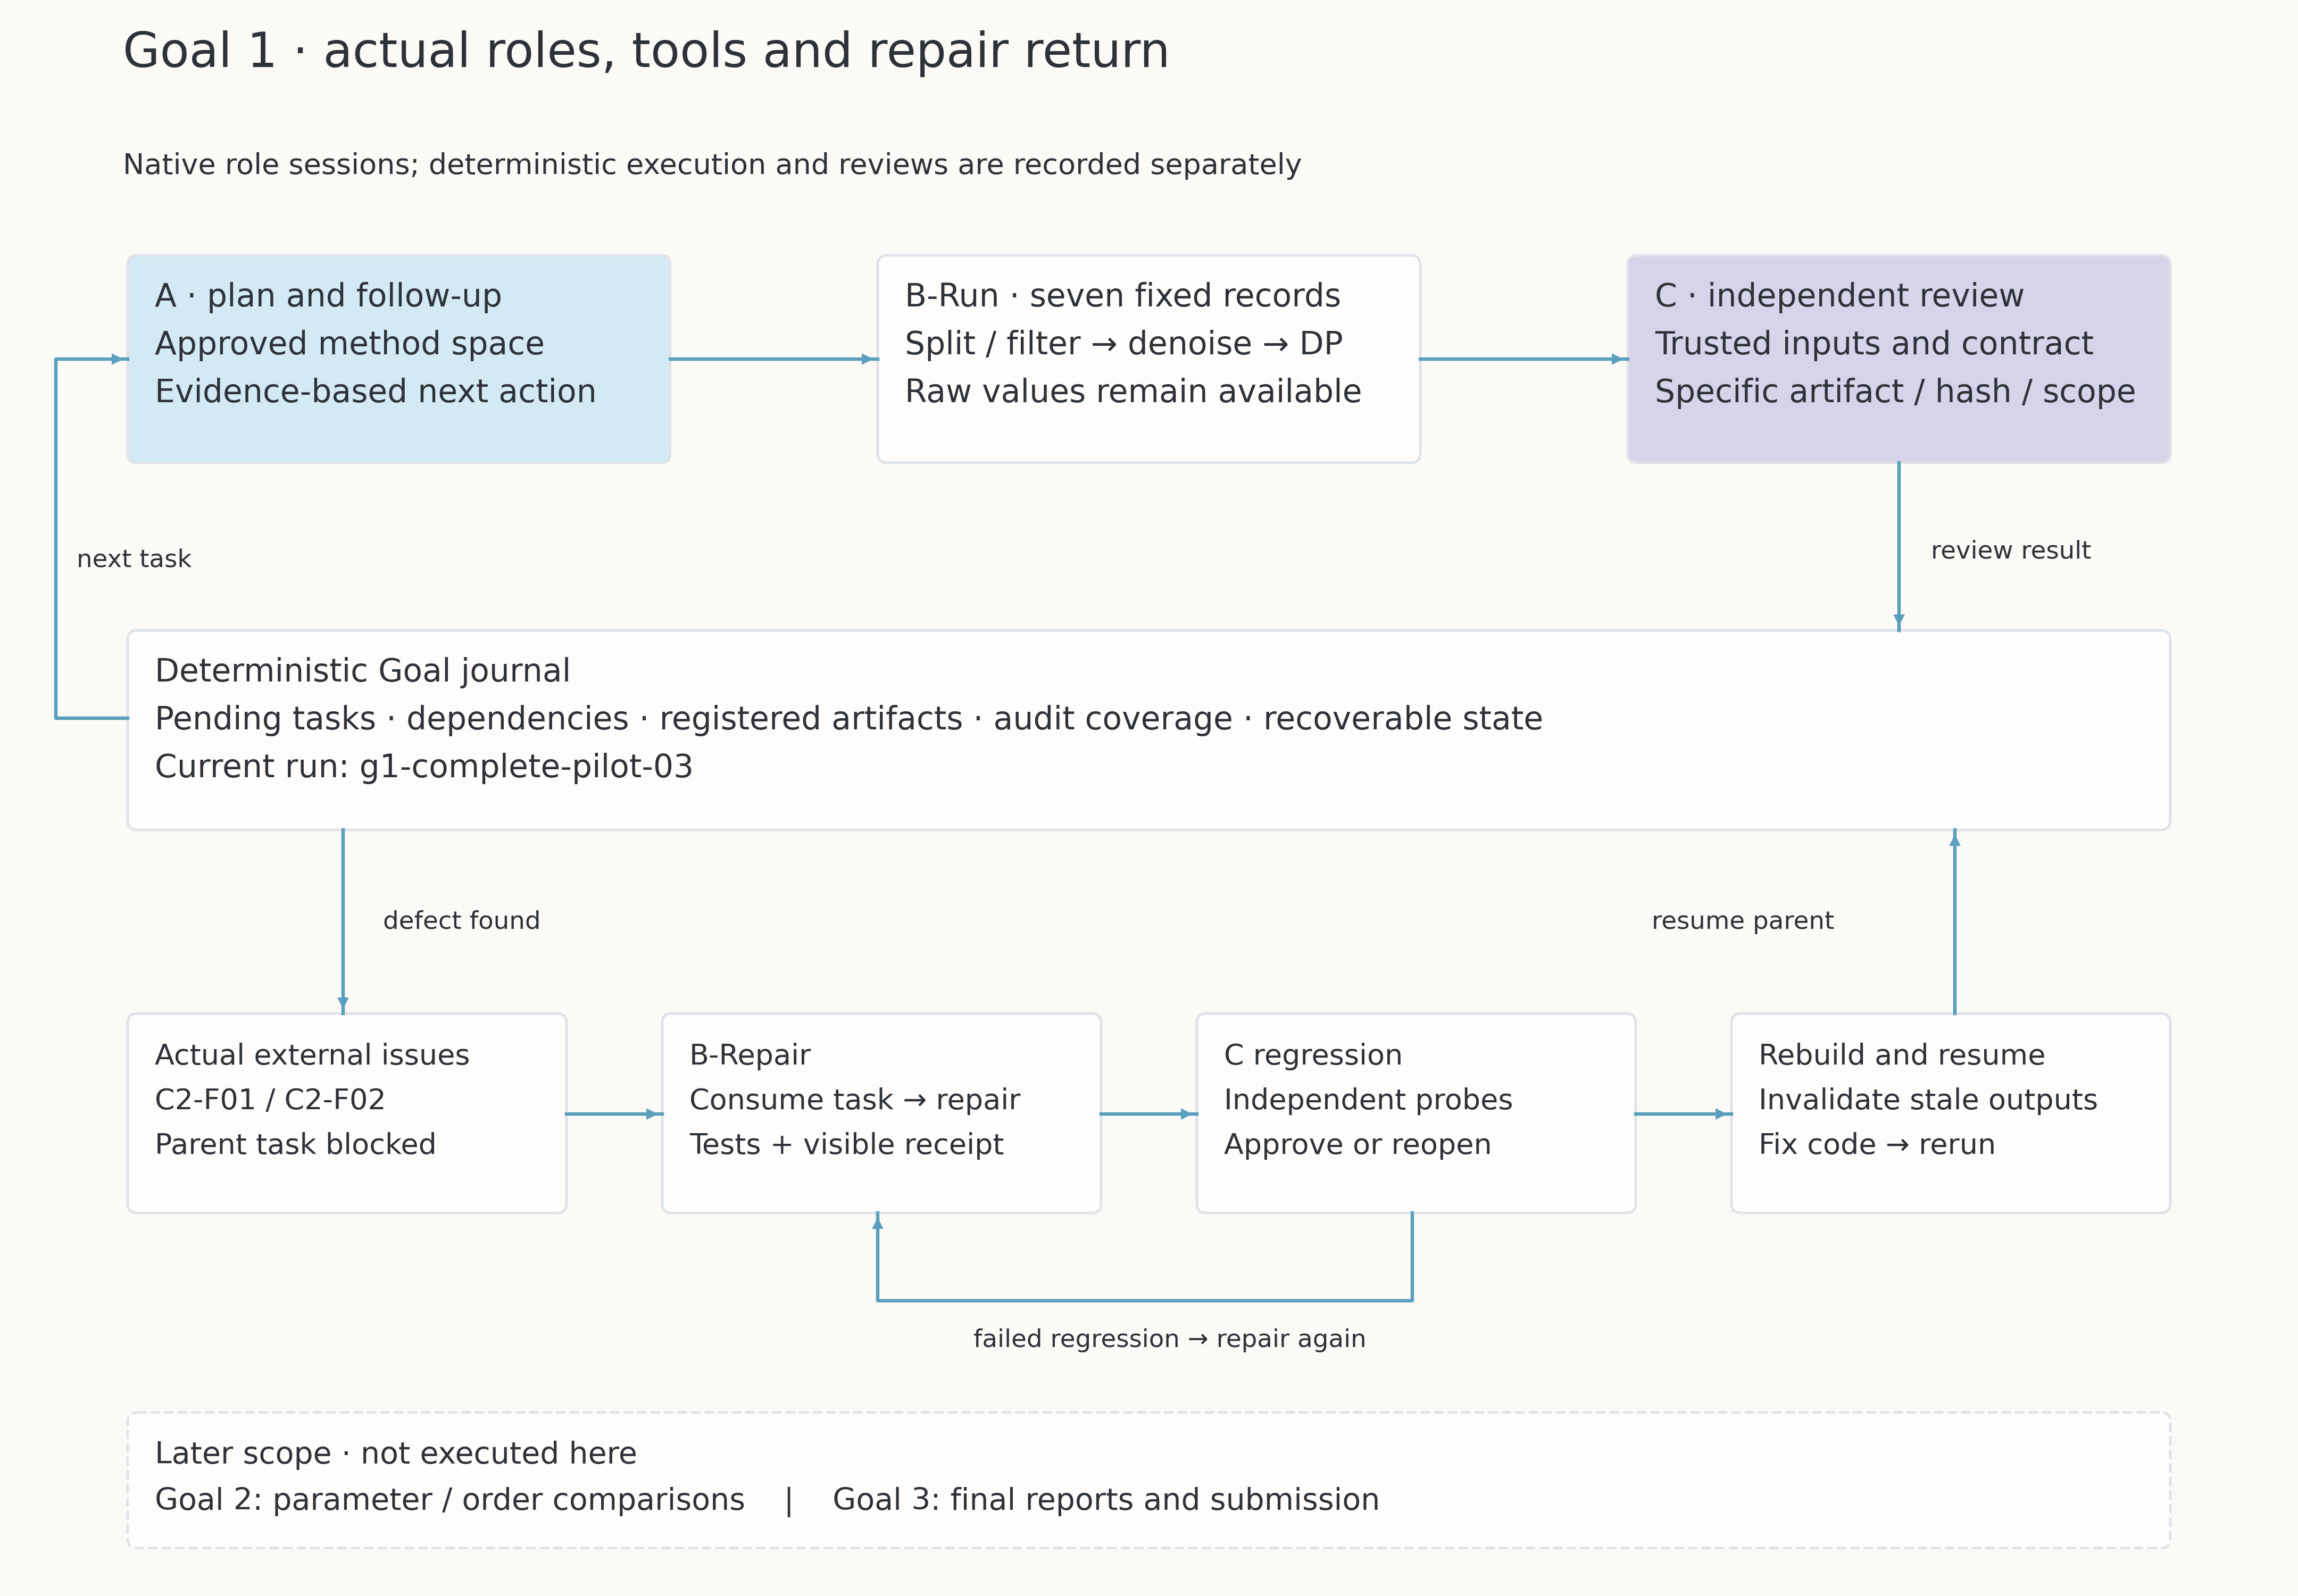

Actual follow-up: {
  "path": "task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/runs/g1-complete-pilot-03/coordinate_sensitivity.json",
  "sha256": "0ccffb15396c6ab1e57cc29fdb3e4ab9879104c73f95679dc1ac09d109d6de9f",
  "source_hashes": {
    "task1/workflow/coordinate_review.py": "af4f0d753d162666bcb5da07edeccb846e008c33adf0f56b34939ac526eaf951",
    "task1/workflow/coordinates.py": "d99b270a65c88f8530669d5e7d0887d7563b3e54e19770ab7a9eb695117e075d",
    "task1/workflow/evaluation.py": "7cf224fbc290d3e83acd5d83a3fe335e6dc437c762f7053d8132817aa91025b2"
  }
}
Trigger: {
  "request": {
    "path": "task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/c_acceptance/followup_request_run03.json",
    "sha256": "baff383be63c53ea1bd5a791c89e170faa7c3cd08b1fa7fc741eeb001e03a707"
  },
  "trigger_review": {
    "path": "task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/runs/g1-complete-pilot-03/baseline_review.json",
    "sha256": "849f1aa9d5415a3f4bd45336181edc0abfe0582997a2332b85bdcc5

In [7]:
figure_manifest=read_json(REVISION/'figures/figure_manifest.json')
assert figure_manifest['run_id']==current['run_id']
display(Image(filename=str(REVISION/'figures/goal1_execution_structure.png'),width=1200))
run_state=state['runs'].get(current['run_id'],{})
followup=run_state.get('followup')
print('Actual follow-up:',json.dumps(followup,ensure_ascii=False,indent=2) if followup else 'NOT_RUN')
if followup:
    assert digest(ROOT/followup['path'])==followup['sha256']
    actual_followup=read_json(ROOT/followup['path'])
    print('Trigger:',json.dumps({k:actual_followup.get(k) for k in ['request','trigger_review','parent_artifact_id','parent_sha256','status']},ensure_ascii=False,indent=2))

## 当前任务状态与解释边界

VERIFIED 表示其明示范围内的工程检查成立；它不是 QUALITY_ACCEPTED、未知真值恢复或项目最终验收。普通工程缺陷继续当前 Goal 的修复循环。最终 GPT 远程二审仍待真实审核；不自动进入 Goal 2/3。

下方是 **Notebook 执行时的 journal 快照**；最终总审查登记在其后。最终状态见 `task1/evidence/goal1/REVIEW_PACKET.md`，不能把执行中快照误称为最终状态。

In [8]:
show_table([{'task':name,'status':row['status'],'depends_on':row['depends_on']} for name,row in state['tasks'].items()])
print('Journal snapshot at Notebook execution:',state['status'])
print('GPT second review:',state['gpt_second_review'])
print('Submission:',state['submission'])
print('Raw unchanged:',digest(DATA)==manifest['input_sha256'])
print('Notebook mode:',MODE,'; default new model calls: 0')
print('Final review is registered after this Notebook run; final status: task1/evidence/goal1/REVIEW_PACKET.md')

task,status,depends_on
governance,PENDING,[]
review_targets,PENDING,[]
trusted_baseline,PENDING,[]
diagnostics,PENDING,"[""review_targets""]"
real_baseline,PENDING,"[""trusted_baseline"", ""diagnostics""]"
processing_feedback,PENDING,"[""real_baseline""]"
notebooks,PENDING,"[""diagnostics""]"
figures,PENDING,"[""diagnostics""]"
internal_review,PENDING,"[""governance"", ""review_targets"", ""trusted_baseline"", ""diagnostics"", ""notebooks"", ""figures""]"


Journal snapshot at Notebook execution: IMPLEMENTING
GPT second review: PENDING
Submission: NOT_READY
Raw unchanged: True
Notebook mode: RECOMPUTE ; default new model calls: 0
Final review is registered after this Notebook run; final status: task1/evidence/goal1/REVIEW_PACKET.md
